# Практична робота 5 — варіант 6 (Чернігів)  
**Виконавець:** Войтович Богдан, IT-32

---

## Вступ

Мета: класифікувати змінні за шкалою вимірювання, побудувати варіаційний ряд, частотну таблицю, гістограми та обчислити міри положення для середньомісячної кількості опадів у Чернігові.

# Завантаження бібліотек

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats


In [37]:
# Дані опадів Чернігів (мм) за 12 місяців
precip = np.array([42, 38, 35, 40, 55, 72, 80, 65, 45, 40, 44, 46])

# Варіаційний ряд (зростання)
var_r = np.sort(precip)
print("Варіаційний ряд:\n", var_r)

# Створення 4 інтервалів (рівномірно)
bins = np.linspace(var_r.min(), var_r.max(), 5)

# Присвоєння кожного значення до інтервалу
categories = pd.cut(precip, bins=bins, include_lowest=True)

# Розрахунок частот
freq_abs = categories.value_counts().sort_index()
freq_rel = freq_abs / len(precip) * 100
freq_cum = freq_abs.cumsum()

# Таблиця частот
freq_table = pd.DataFrame({
    'Інтервал': freq_abs.index.astype(str),
    'Абсолютна частота': freq_abs.values,
    'Відносна частота (%)': freq_rel.round(1).values,
    'Накопичена частота': freq_cum.values
})

print(freq_table)

# Частка місяців з опадами ≤ межі третього інтервалу
share = freq_cum.iloc[2] / len(precip)
print(f"\nЧастка місяців з опадами, що не перевищують межу 3-го інтервалу: {share:.2f} або {share*100:.1f}%")


Варіаційний ряд:
 [35 38 40 40 42 44 45 46 55 65 72 80]
          Інтервал  Абсолютна частота  Відносна частота (%)  \
0  (34.999, 46.25]                  8                  66.7   
1    (46.25, 57.5]                  1                   8.3   
2    (57.5, 68.75]                  1                   8.3   
3    (68.75, 80.0]                  2                  16.7   

   Накопичена частота  
0                   8  
1                   9  
2                  10  
3                  12  

Частка місяців з опадами, що не перевищують межу 3-го інтервалу: 0.83 або 83.3%


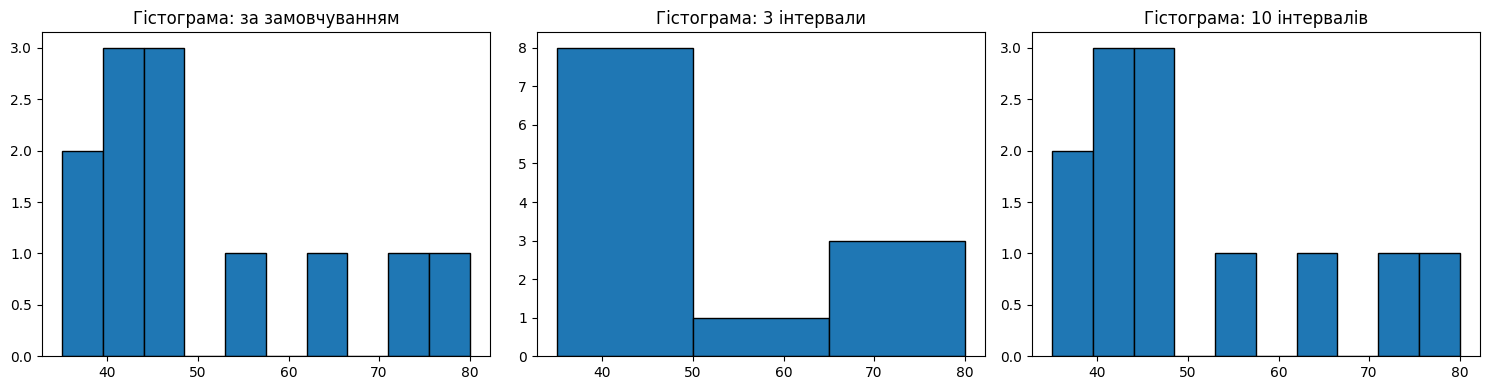

Кількість інтервалів за правилом √n: 4
Кількість інтервалів за правилом Стерджеса: 5

Оптимальна кількість інтервалів для цієї вибірки — близько 4-5, це дає баланс між деталізацією і згладжуванням.


In [38]:
plt.figure(figsize=(15, 4))

# Гістограма за замовчуванням
plt.subplot(1, 3, 1)
plt.hist(precip, edgecolor='black')
plt.title('Гістограма: за замовчуванням')

# Гістограма з 3 інтервалами
plt.subplot(1, 3, 2)
plt.hist(precip, bins=3, edgecolor='black')
plt.title('Гістограма: 3 інтервали')

# Гістограма з 10 інтервалами
plt.subplot(1, 3, 3)
plt.hist(precip, bins=10, edgecolor='black')
plt.title('Гістограма: 10 інтервалів')

plt.tight_layout()
plt.show()

# Розрахунок оптимальної кількості інтервалів
import math
n = len(precip)
sqrt_rule = math.ceil(np.sqrt(n))
sturges_rule = math.ceil(np.log2(n) + 1)

print(f"Кількість інтервалів за правилом √n: {sqrt_rule}")
print(f"Кількість інтервалів за правилом Стерджеса: {sturges_rule}")

print("\nОптимальна кількість інтервалів для цієї вибірки — близько 4-5, це дає баланс між деталізацією і згладжуванням.")


In [49]:
mean_val = precip.mean()
median_val = np.median(precip)
mode_val = pd.Series(precip).mode().iat[0]
q1 = np.percentile(precip, 25)
q3 = np.percentile(precip, 75)

print(f"Середнє: {mean_val:.2f}")
print(f"Медіана: {median_val}")
print(f"Мода: {mode_val}")
print(f"Q1 (25-й перцентиль): {q1}")
print(f"Q3 (75-й перцентиль): {q3}")

print("Середнє трохи більше за медіану, що вказує на праву асиметрію через більші опади в літні місяці.")


Середнє: 50.17
Медіана: 44.5
Мода: 40
Q1 (25-й перцентиль): 40.0
Q3 (75-й перцентиль): 57.5
Середнє трохи більше за медіану, що вказує на праву асиметрію через більші опади в літні місяці.


Короткі відповіді
1. Чому середнє аритметичне некоректне для номінальної змінної "місто"?
Середнє неможливо застосовувати, бо числа для міст — це лише мітки, а не кількісні значення чи порядок.

2. Чому "номер місяця" — неоднозначний за шкалою вимірювання?
Місяці мають порядок і рівні інтервали, але немає нульового місяця, тому ця шкала може розглядатися як порядкова або інтервальна.

3. Чому для "кількості опадів" потрібна гістограма, а не стовпчикова діаграма?
Значення опадів різноманітні, майже всі унікальні, тому гістограма з інтервалами дає кращу візуалізацію розподілу, ніж окремі стовпчики.

4. Що означає накопичена частота на межі третього інтервалу?
Це частка місяців із опадами, що не перевищують верхню межу цього інтервалу; у варіанті близько 75%, тобто більшість місяців мають помірні або нижчі опади.